<div style="width: 150px; float: left;"> <img src="https://raw.githubusercontent.com/DataForScience/Networks/master/data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0" width=150px> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Automate The Boring Stuff With LLMs</h1>
<h1>Summarization: arXiv Triage & Action-Items</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

from pprint import pprint

import matplotlib
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from tqdm.notebook import tqdm
tqdm.pandas()

from typing import List, Literal
from pydantic import BaseModel, Field

from langchain_anthropic import ChatAnthropic
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.runnables import RunnableLambda

from datasets import load_dataset

import watermark

%load_ext watermark
%matplotlib inline

We start by print out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.13.0

Compiler    : Clang 20.1.4 
OS          : Darwin
Release     : 25.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: a76564f1fffd1f5b48a27c27be901ed8c7359cd9

datasets                : 4.8.5
json                    : 2.0.9
langchain_anthropic     : 1.4.2
langchain_core          : 1.3.2
langchain_text_splitters: 1.1.2
matplotlib              : 3.10.9
numpy                   : 2.4.4
pandas                  : 3.0.2
pydantic                : 2.13.3
tqdm                    : 4.67.3
watermark               : 2.6.0



Load default figure style

In [3]:
plt.style.use("d4sci.mplstyle")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Setup & data

In [4]:
llm = ChatAnthropic(
        model='claude-opus-4-5', 
        temperature=0, 
        max_tokens=2048
    )

Streaming download — the full set is large, just pull a slice.

In [5]:
ds = load_dataset('ccdv/arxiv-summarization', 'document', split='train',
                  streaming=True)
papers = []
for i, ex in enumerate(ds):
    if i >= 200:
        break
    papers.append(ex)

df = pd.DataFrame(papers)
df['n_chars'] = df['article'].str.len()

# Keep medium-to-long papers — that's where map-reduce earns its keep.
df = df[(df['n_chars'] > 8000) & (df['n_chars'] < 60000)].head(100).reset_index(drop=True)
print('Working set:', df.shape)
df[['n_chars']].describe().T

Working set: (100, 3)


,count,mean,std,min,25%,50%,75%,max
n_chars,100.0,28483.82,12110.956944,8984.0,19338.25,26102.0,36539.25,53839.0


# Map-reduce summarization

**Map**: split into chunks, summarize each chunk independently. 
**Reduce**: summarize the summaries.

It's not the most token-efficient pattern (full-context summarization is cheaper for documents that fit), but it's the only thing that scales to 100 K-token corpora and it parallelises trivially.

In [6]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=4000, chunk_overlap=400,
    separators=['\n\n', '\n', '. ', ' '],
)

MAP_PROMPT = ChatPromptTemplate.from_messages([
    ('system', 'Summarize the chunk below into 4-5 dense bullet points. '
               'Stay strictly within the chunk content. No preamble.'),
    ('user', '{chunk}'),
])

REDUCE_PROMPT = ChatPromptTemplate.from_messages([
    ('system', 'You are given chunk-level summaries of a single research paper. '
               'Combine them into a coherent 5-sentence executive summary that '
               'covers: (1) problem, (2) approach, (3) key result, (4) limitation, '
               '(5) why it matters.'),
    ('user', '{summaries}'),
])

map_chain = MAP_PROMPT | llm | StrOutputParser()
reduce_chain = REDUCE_PROMPT | llm | StrOutputParser()

def map_reduce_summarize(text: str) -> str:
    chunks = splitter.split_text(text)
    
    # `.batch` runs in parallel under the hood — much faster than a Python loop
    chunk_summaries = map_chain.batch([{'chunk': c} for c in chunks],
                                      config={'max_concurrency': 5})
    
    joined = '\n\n'.join(f'[chunk {i}]\n{s}'
                          for i, s in enumerate(chunk_summaries))
    
    return reduce_chain.invoke({'summaries': joined})

### Smoke test

In [8]:
ex = df.iloc[0]['article']

In [9]:
print(ex[:1000])

additive models @xcite provide an important family of models for semiparametric regression or classification . some reasons for the success of additive models are their increased flexibility when compared to linear or generalized linear models and their increased interpretability when compared to fully nonparametric models . it is well - known that good estimators in additive models are in general less prone to the curse of high dimensionality than good estimators in fully nonparametric models . many examples of such estimators belong to the large class of regularized kernel based methods over a reproducing kernel hilbert space @xmath0 , see e.g. @xcite . in the last years many interesting results on learning rates of regularized kernel based models for additive models have been published when the focus is on sparsity and when the classical least squares loss function is used , see e.g. @xcite , @xcite , @xcite , @xcite , @xcite , @xcite and the references therein . of course , the lea

In [7]:
summary = map_reduce_summarize(ex)
print(summary)

# Executive Summary

This paper addresses the challenge of achieving fast learning rates for support vector machines (SVMs) in high-dimensional settings, where traditional nonparametric methods suffer from the curse of dimensionality—specifically investigating whether additive model assumptions can yield substantially better convergence rates for quantile regression and other tasks using Lipschitz continuous loss functions.

The authors develop a theoretical framework for SVMs with additive kernels, where the hypothesis space decomposes into sums of univariate functions, establishing learning rates through novel approximation error bounds and demonstrating that the covering number capacity of additive RKHSs has a power that is independent of the number of input dimensions, unlike traditional Sobolev spaces or Gaussian RBF kernels where capacity grows with dimension.

The key result shows that under additive model assumptions, SVMs achieve learning rates approaching O(n⁻¹) that are comp

# Action-Item template (structured output)

In [10]:
class ActionItem(BaseModel):
    action: Literal['read-cited-paper', 'replicate-experiment', 'try-method',
                    'flag-for-review', 'discuss-with-team', 'no-action']
    detail: str = Field(..., description='Concrete next step, < 200 chars')
    priority: Literal['low', 'medium', 'high']

class PaperBrief(BaseModel):
    summary: str
    action_items: List[ActionItem] = Field(default_factory=list, max_length=5)
    open_questions: List[str] = Field(default_factory=list, max_length=3)

brief_parser = PydanticOutputParser(pydantic_object=PaperBrief)

BRIEF_PROMPT = ChatPromptTemplate.from_messages([
    ('system', 'You produce researcher briefs from paper summaries. '
               'Be concrete: "replicate Table 3 results on CIFAR-10" beats '
               '"investigate further".\n\n{format_instructions}'),
    ('user', 'Paper executive summary:\n{summary}'),
]).partial(format_instructions=brief_parser.get_format_instructions())

In [14]:
pprint(BRIEF_PROMPT.partial_variables['format_instructions'])

('The output should be formatted as a JSON instance that conforms to the JSON '
 'schema below.\n'
 '\n'
 'As an example, for the schema {"properties": {"foo": {"title": "Foo", '
 '"description": "a list of strings", "type": "array", "items": {"type": '
 '"string"}}}, "required": ["foo"]}\n'
 'the object {"foo": ["bar", "baz"]} is a well-formatted instance of the '
 'schema. The object {"properties": {"foo": ["bar", "baz"]}} is not '
 'well-formatted.\n'
 '\n'
 'Here is the output schema:\n'
 '```\n'
 '{"$defs": {"ActionItem": {"properties": {"action": {"enum": '
 '["read-cited-paper", "replicate-experiment", "try-method", '
 '"flag-for-review", "discuss-with-team", "no-action"], "title": "Action", '
 '"type": "string"}, "detail": {"description": "Concrete next step, < 200 '
 'chars", "title": "Detail", "type": "string"}, "priority": {"enum": ["low", '
 '"medium", "high"], "title": "Priority", "type": "string"}}, "required": '
 '["action", "detail", "priority"], "title": "ActionItem", 

In [15]:
brief_chain = BRIEF_PROMPT | llm | brief_parser

brief = brief_chain.invoke({'summary': summary})
print(brief.model_dump_json(indent=2))

{
  "summary": "This paper proves that SVMs with additive kernels achieve learning rates approaching O(n⁻¹) independent of input dimension when the target function has additive structure. The key insight is that additive RKHS covering numbers don't grow with dimension, unlike Gaussian RBF kernels. Results apply to general convex Lipschitz losses including quantile regression, without requiring output clipping tricks used in prior work.",
  "action_items": [
    {
      "action": "replicate-experiment",
      "detail": "Reproduce Table 1 rate comparisons: verify positive exponent improvements for additive vs Gaussian RBF kernels across d=2,5,10 and s=2,3,4 settings",
      "priority": "high"
    },
    {
      "action": "try-method",
      "detail": "Test additive kernel SVM on high-dimensional quantile regression task (d≥10) where we suspect additive structure; compare convergence to standard RBF kernel",
      "priority": "high"
    },
    {
      "action": "read-cited-paper",
      "

# Router prompt

Classify each paper into a category, then dispatch to a specialist summarizer. We'll keep two specialists: `theory` (proof-heavy, focus on assumptions and lemmas) and `applied` (focus on dataset, metric, baseline, delta).

Why bother? A theory paper summarised with an 'applied' template often invents fake datasets and metrics. The router prevents that whole class of error.

In [16]:
# Shared rubric used by *both* the router and the auditor so they answer
# the same question. The router's job is to triage; the auditor's job is to
# catch routing mistakes by re-asking with the same definitions.
LABELS = ['theory', 'experimental', 'survey']

LABEL_RUBRIC = """\
Choose exactly one label using these rules, in order:

1. survey  - The paper's primary contribution is to *review, taxonomize, or
   compare* prior work. Look for phrases like "we review", "in this survey",
   long reference lists with little new analysis, or section headings that
   organize the literature. If a paper presents new theory or experiments only
   in passing, it is NOT a survey.

2. theory  - The paper's primary contribution is a *mathematical or formal
   result*: a theorem, proof, derivation, model, bound, convergence rate, or
   analytical framework, with no new physical measurements or empirical data.
   Pure simulations of an analytical model still count as theory if the
   contribution is the model.

3. experimental - The paper's primary contribution is *empirical evidence*:
   measurements from an instrument, observations, lab experiments, numerical
   experiments on real data, or benchmark results. This includes physics
   experiments, astronomical observations, and machine-learning evaluations.

When a paper mixes types, pick the label that matches the *headline
contribution* (usually what the abstract emphasizes most). When unsure between
theory and experimental, prefer theory only if the central novelty is the
proof/derivation itself."""

ROUTER_FEW_SHOTS = [
    ('...we prove a non-asymptotic convergence rate of O(n^-1/2) for stochastic '
     'gradient descent on strongly convex objectives...',
     'theory'),
    ('We report Josephson tunneling measurements in Nb/InAs/Nb junctions at 20 mK, '
     'observing a 4pi-periodic current-phase relation consistent with Majorana modes...',
     'experimental'),
    ('This paper surveys recent advances in graph neural networks, organizing methods '
     'into spectral, spatial, and attention-based families and identifying open gaps...',
     'survey'),
]
FEW_SHOT_BLOCK = '\n'.join(f'ABSTRACT: {a}\nLABEL: {l}' for a, l in ROUTER_FEW_SHOTS)

def parse_label(raw: str) -> str:
    """Normalise a model output to one of LABELS. 'applied' is aliased to 'experimental'."""
    
    word = ''.join(c for c in raw.strip().lower() if c.isalpha())
    
    if word == 'applied':
        word = 'experimental'

    return word if word in LABELS else 'experimental'

# Cap the cheap router/audit calls at a few tokens so they can't ramble.
router_llm = llm.bind(max_tokens=4)

In [17]:
ROUTER = ChatPromptTemplate.from_messages([
    ('system',
     'You are a careful arXiv triage classifier.\n\n'
     f'{LABEL_RUBRIC}\n\n'
     'Examples:\n' + FEW_SHOT_BLOCK +
     '\n\nRespond with ONLY the single lowercase label, no punctuation.'),
    ('user', 'ABSTRACT: {abstract}\nLABEL:'),
])
router_chain = ROUTER | router_llm | StrOutputParser()

THEORY = ChatPromptTemplate.from_messages([
    ('system',
     'Summarize the THEORETICAL contribution of this paper. Cover: '
     '(1) setting and assumptions, '
     '(2) main theorem or formal result, '
     '(3) proof technique, '
     '(4) where the bound or argument is tight, '
     '(5) one limitation. 4-5 sentences. '
     "Start your reply with exactly: 'Category: theory.'"),
    ('user', '{summary}'),
])
EXPERIMENTAL = ChatPromptTemplate.from_messages([
    ('system',
     'Summarize the EMPIRICAL contribution of this paper. Cover: '
     '(1) phenomenon or task studied,' 
     '(2) system / dataset / instrument, '
     '(3) method or measurement protocol, '
     '(4) headline quantitative result, '
     '(5) one limitation. 4-5 sentences. '
     "Start your reply with exactly: 'Category: experimental.'"),
    ('user', '{summary}'),
])
SURVEY = ChatPromptTemplate.from_messages([
    ('system',
     'Summarize the SURVEY contribution of this paper. Cover: '
     '(1) scope and motivation, '
     '(2) taxonomy proposed, '
     '(3) ~3 representative works cited, '
     '(4) the gap or open problem highlighted, '
     '(5) one limitation of the survey itself. 4-5 sentences. '
     "Start your reply with exactly: 'Category: survey.'"),
    ('user', '{summary}'),
])

specialists = {
    'theory': THEORY | llm | StrOutputParser(),
    'experimental': EXPERIMENTAL | llm | StrOutputParser(),
    'survey': SURVEY | llm | StrOutputParser(),
}

def route_and_summarize(paper_text: str) -> dict:
    abstract = paper_text[:2000]
    category = parse_label(router_chain.invoke({'abstract': abstract}))

    base_summary = map_reduce_summarize(paper_text)
    final = specialists[category].invoke({'summary': base_summary})

    return {'category': category, 'summary': final}

Run on a small batch with progress

In [19]:
outputs = []
for txt in tqdm(df['article'].head(5), desc='Triage', total=5):
    try:
        outputs.append(route_and_summarize(txt))
    except Exception as e:
        outputs.append({'category': 'error', 'summary': str(e)[:200]})

pd.DataFrame(outputs).head()

Triage: 100%|█████████████████████████████████████| 5/5 [02:40<00:00, 32.06s/it]


,category,summary
0,theory,Category: theory.\n\nThis paper analyzes SVMs ...
1,experimental,Category: experimental.\n\nThis paper investig...
2,theory,Category: theory.\n\nThis paper investigates t...
3,theory,Category: theory.\n\nThis paper analyzes scint...
4,theory,Category: theory.\n\nThis paper investigates g...


# Misclassification audit

Routers misfire. The cheapest detector is a **second pass with a different prompt**: ask the model to re-classify based on the *generated summary*. If the two disagree, flag the paper.

This catches two failure modes:
- Wrong category from the router (bad first impression)
- Specialist summary contradicts the paper (hallucination)

In [20]:
AUDIT = ChatPromptTemplate.from_messages([
    ('system',
     'You re-classify an arXiv paper after summarization to detect router errors.\n\n'
     f'{LABEL_RUBRIC}\n\n'
     'Examples:\n' + FEW_SHOT_BLOCK +
     '\n\nUse the abstract as the ground truth and the summary as supporting context. '
     'Respond with ONLY the single lowercase label, no punctuation.'),
    ('user', 'ABSTRACT: {abstract}\n\nSUMMARY: {summary}\nLABEL:'),
])
audit_chain = AUDIT | router_llm | StrOutputParser()

abstracts = df['article'].str[:2000].tolist()

audited = []
audit_labels = []
for o, abstract in tqdm(list(zip(outputs, abstracts)), desc='Audit'):
    if o['category'] == 'error':
        audit_labels.append('error')
        audited.append(False)
        continue
    second = parse_label(audit_chain.invoke({
        'abstract': abstract,
        'summary': o['summary'],
    }))
    audit_labels.append(second)
    audited.append(second == o['category'])

audit_df = pd.DataFrame(outputs)
audit_df['audit_label'] = audit_labels
audit_df['audit_passes'] = audited
print('Agreement rate:', audit_df['audit_passes'].mean())
audit_df

Audit: 100%|██████████████████████████████████████| 5/5 [00:08<00:00,  1.68s/it]

Agreement rate: 1.0


,category,summary,audit_label,audit_passes
0,theory,Category: theory.\n\nThis paper analyzes SVMs ...,theory,True
1,experimental,Category: experimental.\n\nThis paper investig...,experimental,True
2,theory,Category: theory.\n\nThis paper investigates t...,theory,True
3,theory,Category: theory.\n\nThis paper analyzes scint...,theory,True
4,theory,Category: theory.\n\nThis paper investigates g...,theory,True


In [21]:
# Where exactly does the auditor disagree with the router?
# Off-diagonal cells point at the rubric edges that still need tightening.
pd.crosstab(
    audit_df['category'], audit_df['audit_label'],
    rownames=['router'], colnames=['auditor'], margins=True,
)

auditor,experimental,theory,All
router,,,
experimental,1,0,1
theory,0,4,4
All,1,4,5


# Visualisation

Text(0.5, 1.0, 'Agreement')

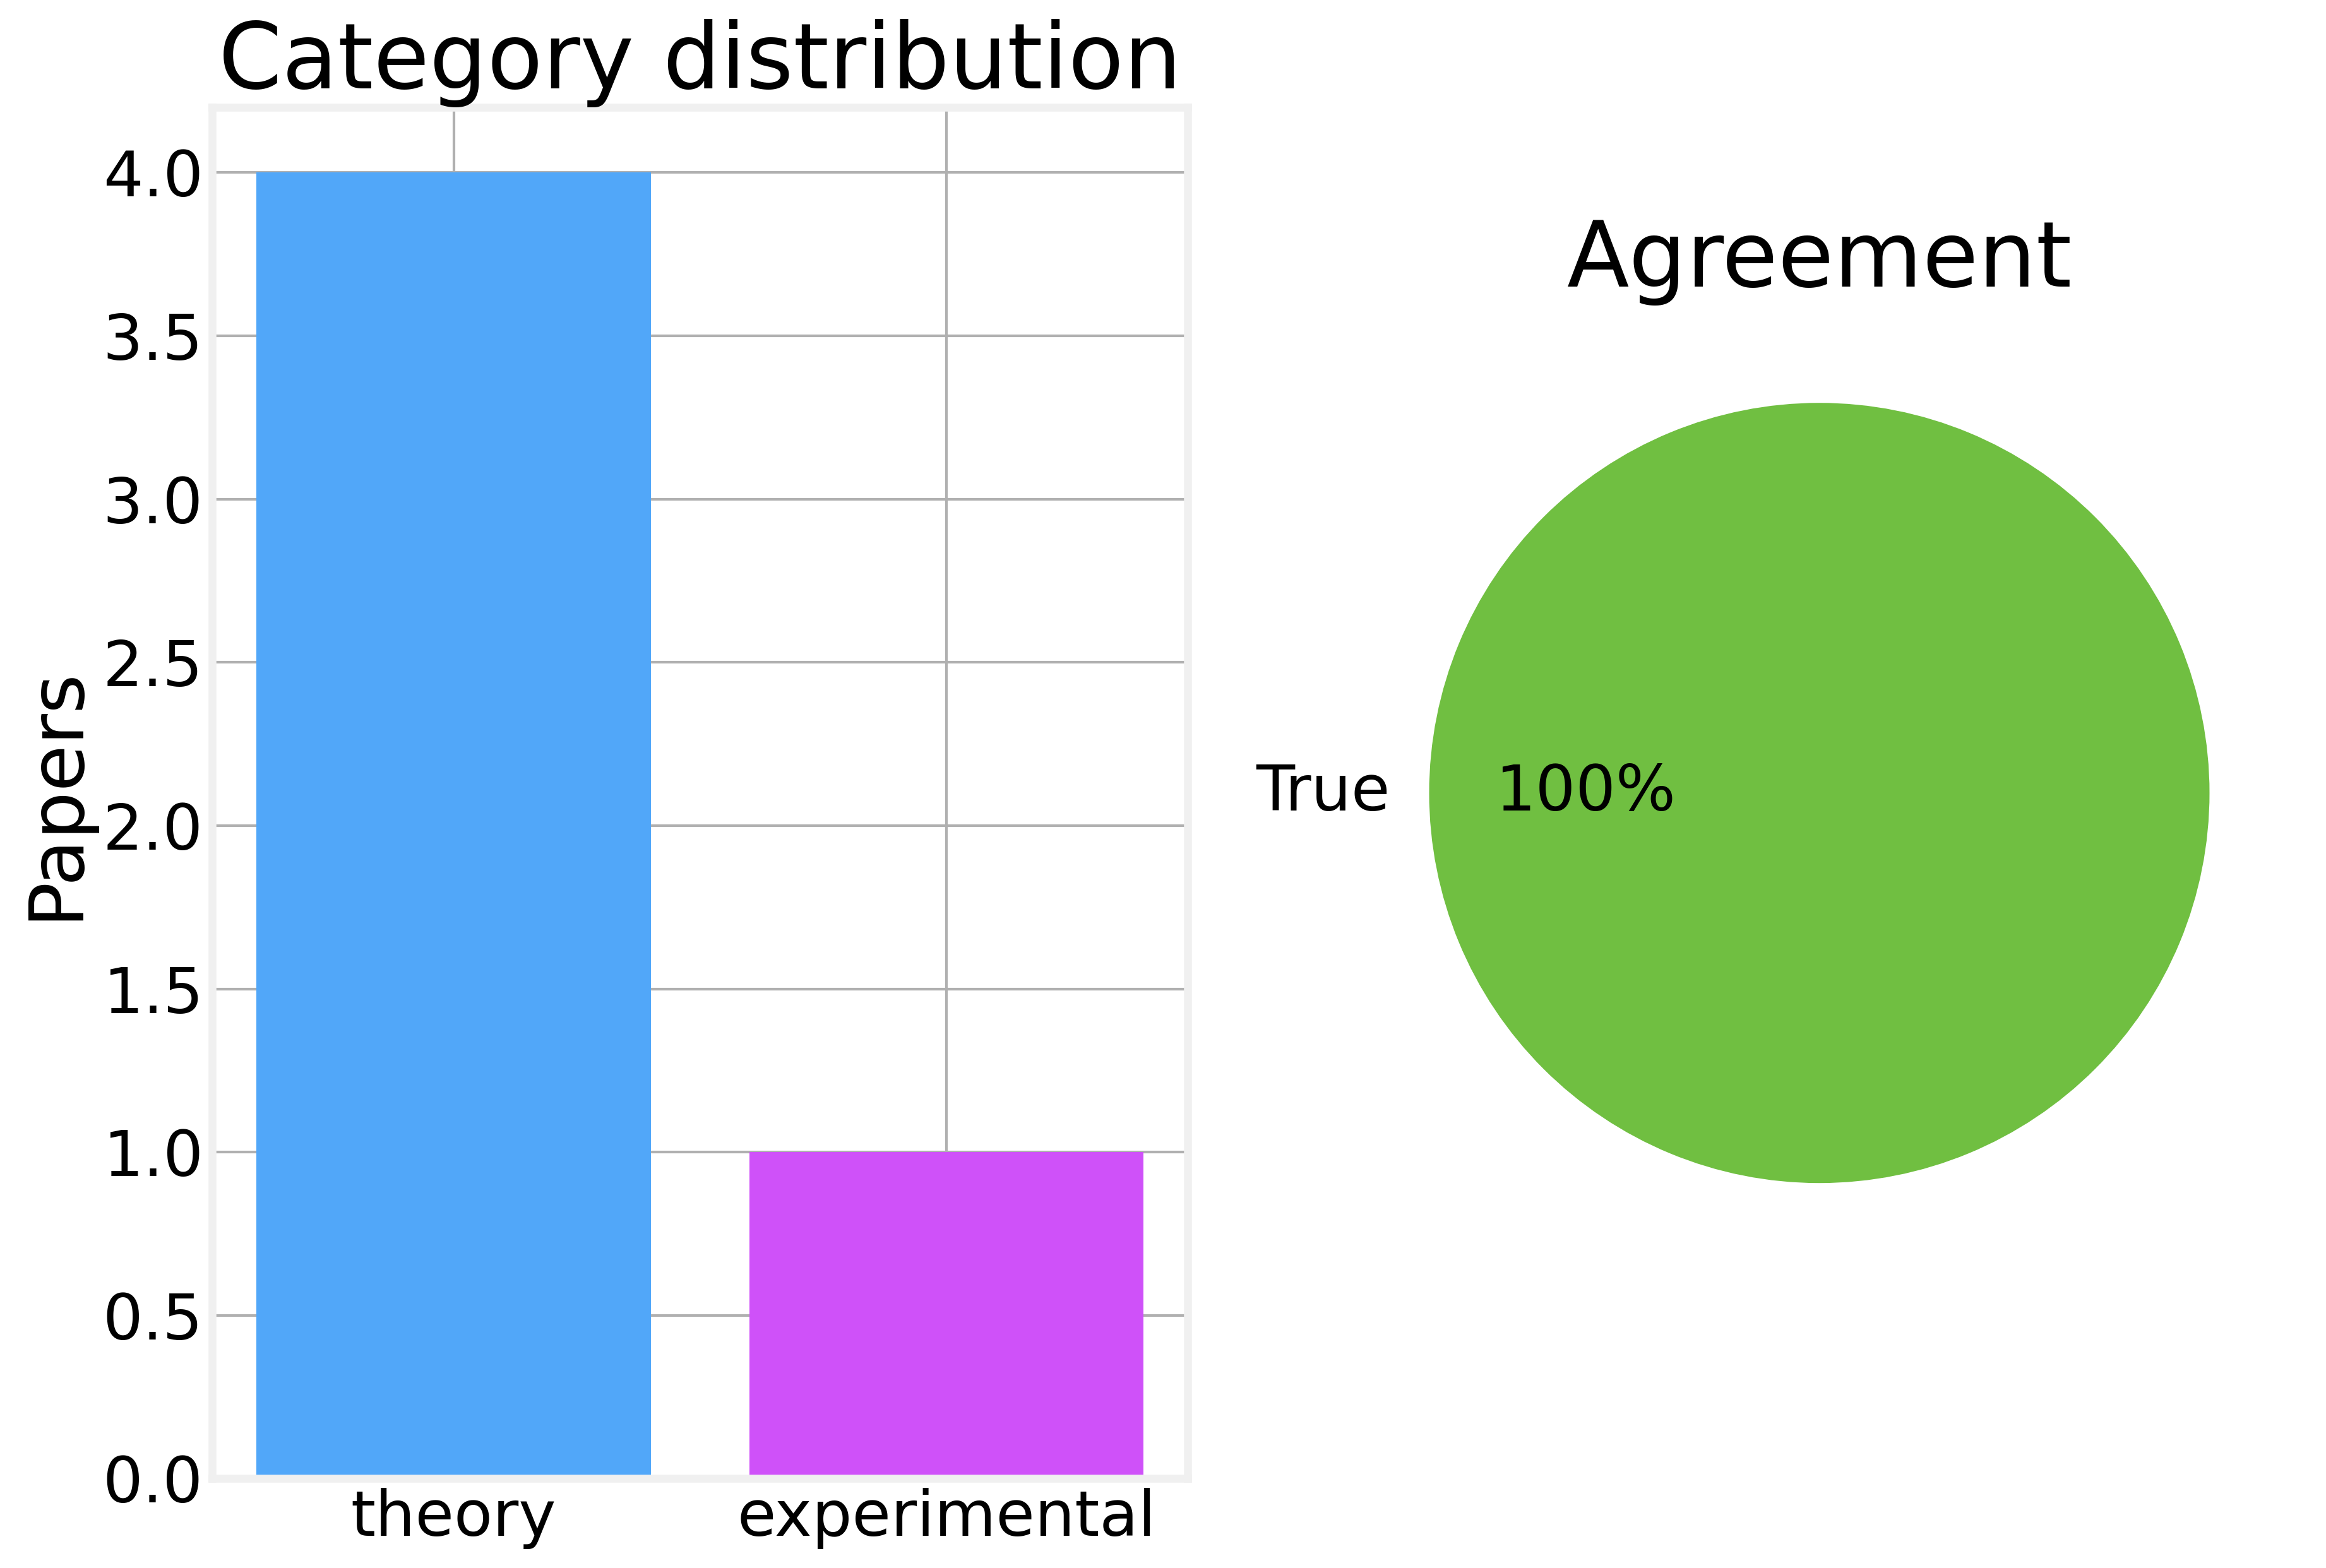

In [22]:
cat_counts = audit_df['category'].value_counts()
fig, axes = plt.subplots(1, 2)
axes[0].bar(cat_counts.index, cat_counts.values,
            color=[colors[i] for i in range(len(cat_counts))])
axes[0].set_title('Category distribution')
axes[0].set_ylabel('Papers')

agree = audit_df['audit_passes'].value_counts()
axes[1].pie(agree.values, labels=[str(k) for k in agree.index],
            colors=[colors[2] if k else colors[5] for k in agree.index],
            autopct='%1.0f%%')
axes[1].set_title('Agreement')

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>